# Question 2 — Classification
Using Decision Trees to classify whether a song would be liked by Sriharsha or Janya.

A song is considered liked if the user has played it 3 or more times(most balanced split)

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')

BASE = os.path.abspath('.')


## 1. Load Data

In [ ]:
def load_user(folder):
    records = []
    for i in range(5):
        try:
            records += json.load(open(f'{BASE}/public/{folder}/StreamingHistory_music_{i}.json', encoding='utf-8'))
        except FileNotFoundError:
            break
    df = pd.DataFrame(records)
    df = df[df['msPlayed'] >= 5000].copy()
    df['minutes'] = df['msPlayed'] / 60000
    df['track_key'] = df['trackName'] + ' | ' + df['artistName']
    df['endTime'] = pd.to_datetime(df['endTime'], utc=True).dt.tz_convert('America/Chicago')
    df['hour'] = df['endTime'].dt.hour
    df['dow'] = df['endTime'].dt.dayofweek
    df['month'] = df['endTime'].dt.month
    df['date'] = df['endTime'].dt.date
    return df

sri = load_user('s')
jan = load_user('j')
track_info = json.load(open(f'{BASE}/public/track_info.json', encoding='utf-8'))

ALL_FEATURES = ['energy', 'danceability', 'happiness', 'acousticness',
                'instrumentalness', 'liveness', 'speechiness', 'tempo', 'popularity',
                'loudness_db', 'duration_sec', 'mode', 'artist_encoded']

# --- Tune these thresholds based on user input ---
SRI_LIKED_THRESHOLD = 3
JAN_LIKED_THRESHOLD = 3

print(f'Sriharsha: {len(sri):,} plays | Janya: {len(jan):,} plays')
print(f'Track info cache: {len(track_info):,} tracks')
print(f'Thresholds — Sri: {SRI_LIKED_THRESHOLD} plays | Janya: {JAN_LIKED_THRESHOLD} plays')

## 2. Build Labeled Dataset

In [3]:
def build_dataset(df, liked_threshold):
    rows = []
    for track_key, group in df.groupby('track_key'):
        info = track_info.get(track_key)
        if info:
            base_feats = ['energy','danceability','happiness','acousticness',
                         'instrumentalness','liveness','speechiness','tempo','popularity']
            feat = {f: info.get(f) for f in base_feats}
            if all(v is not None for v in feat.values()):
                # loudness: strip ' dB' and convert to float
                loudness = info.get('loudness')
                if loudness is None: continue
                try: feat['loudness_db'] = float(str(loudness).replace(' dB',''))
                except: continue
                # duration: convert 'M:SS' to seconds
                duration = info.get('duration')
                if duration is None: continue
                try:
                    parts = str(duration).split(':')
                    feat['duration_sec'] = int(parts[0])*60 + int(parts[1])
                except: continue
                # mode: major=1, minor=0
                mode = info.get('mode')
                if mode is None: continue
                feat['mode'] = 1 if str(mode).lower() == 'major' else 0
                # key: convert to numeric
                key_map = {'C':0,'C#':1,'Db':1,'D':2,'D#':3,'Eb':3,'E':4,'F':5,
                           'F#':6,'Gb':6,'G':7,'G#':8,'Ab':8,'A':9,'A#':10,'Bb':10,'B':11}
                key = info.get('key')
                if key is None: continue
                feat['key'] = key_map.get(str(key), -1)
                if feat['key'] == -1: continue
                feat['liked'] = int(len(group) >= liked_threshold)
                rows.append(feat)
    return pd.DataFrame(rows)

sri_df = build_dataset(sri, SRI_LIKED_THRESHOLD)
jan_df = build_dataset(jan, JAN_LIKED_THRESHOLD)

print(f'Sri  — total: {len(sri_df):,} | liked: {sri_df["liked"].sum():,} ({100*sri_df["liked"].mean():.1f}%)')
print(f'Janya — total: {len(jan_df):,} | liked: {jan_df["liked"].sum():,} ({100*jan_df["liked"].mean():.1f}%)')

Sri  — total: 2,889 | liked: 1,407 (48.7%)
Janya — total: 3,243 | liked: 1,301 (40.1%)


## Builing Labeled Dataset

For each unique track in a user's streaming history, we are pulling audio features from track_info.json. These features include energy, sensibility, happiness, acousticness, instrumentalness, liveness, tempo, popularity, loudness, artist encoded, etc. All of these features are then fed as input into the decision tree(X), And play count(Y) determines Whether a song is liked by the user or not. If the song is played three or more times than it is liked and if not then otherwise. We chose 3 specifically, as Janya and Sri agreed that 3 replays signified that they liked a song. Resulting splits from this decision were 33% liked for Sri and 25.6% liked for Janya.

## 3. Train Decision Trees

=== Sriharsha ===
Train accuracy: 0.5980 | Test accuracy: 0.5536
              precision    recall  f1-score   support

   Not Liked       0.58      0.48      0.53       297
       Liked       0.53      0.63      0.58       281

    accuracy                           0.55       578
   macro avg       0.56      0.56      0.55       578
weighted avg       0.56      0.55      0.55       578



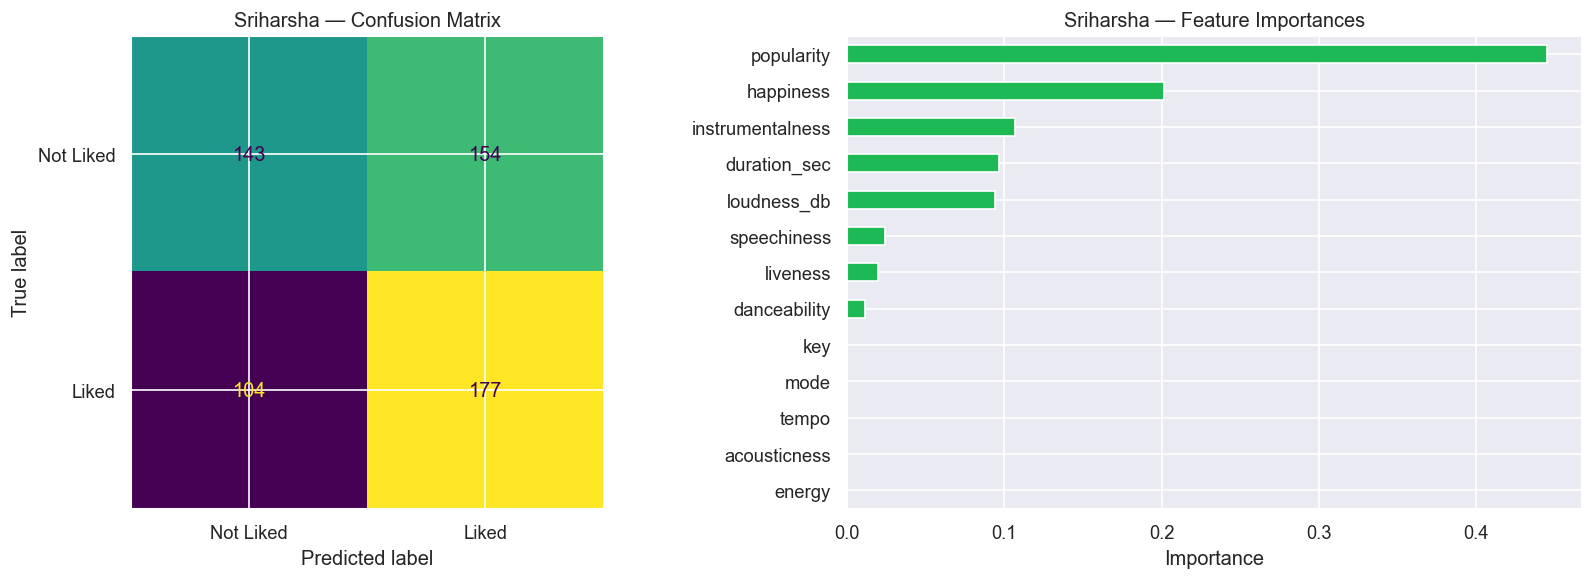

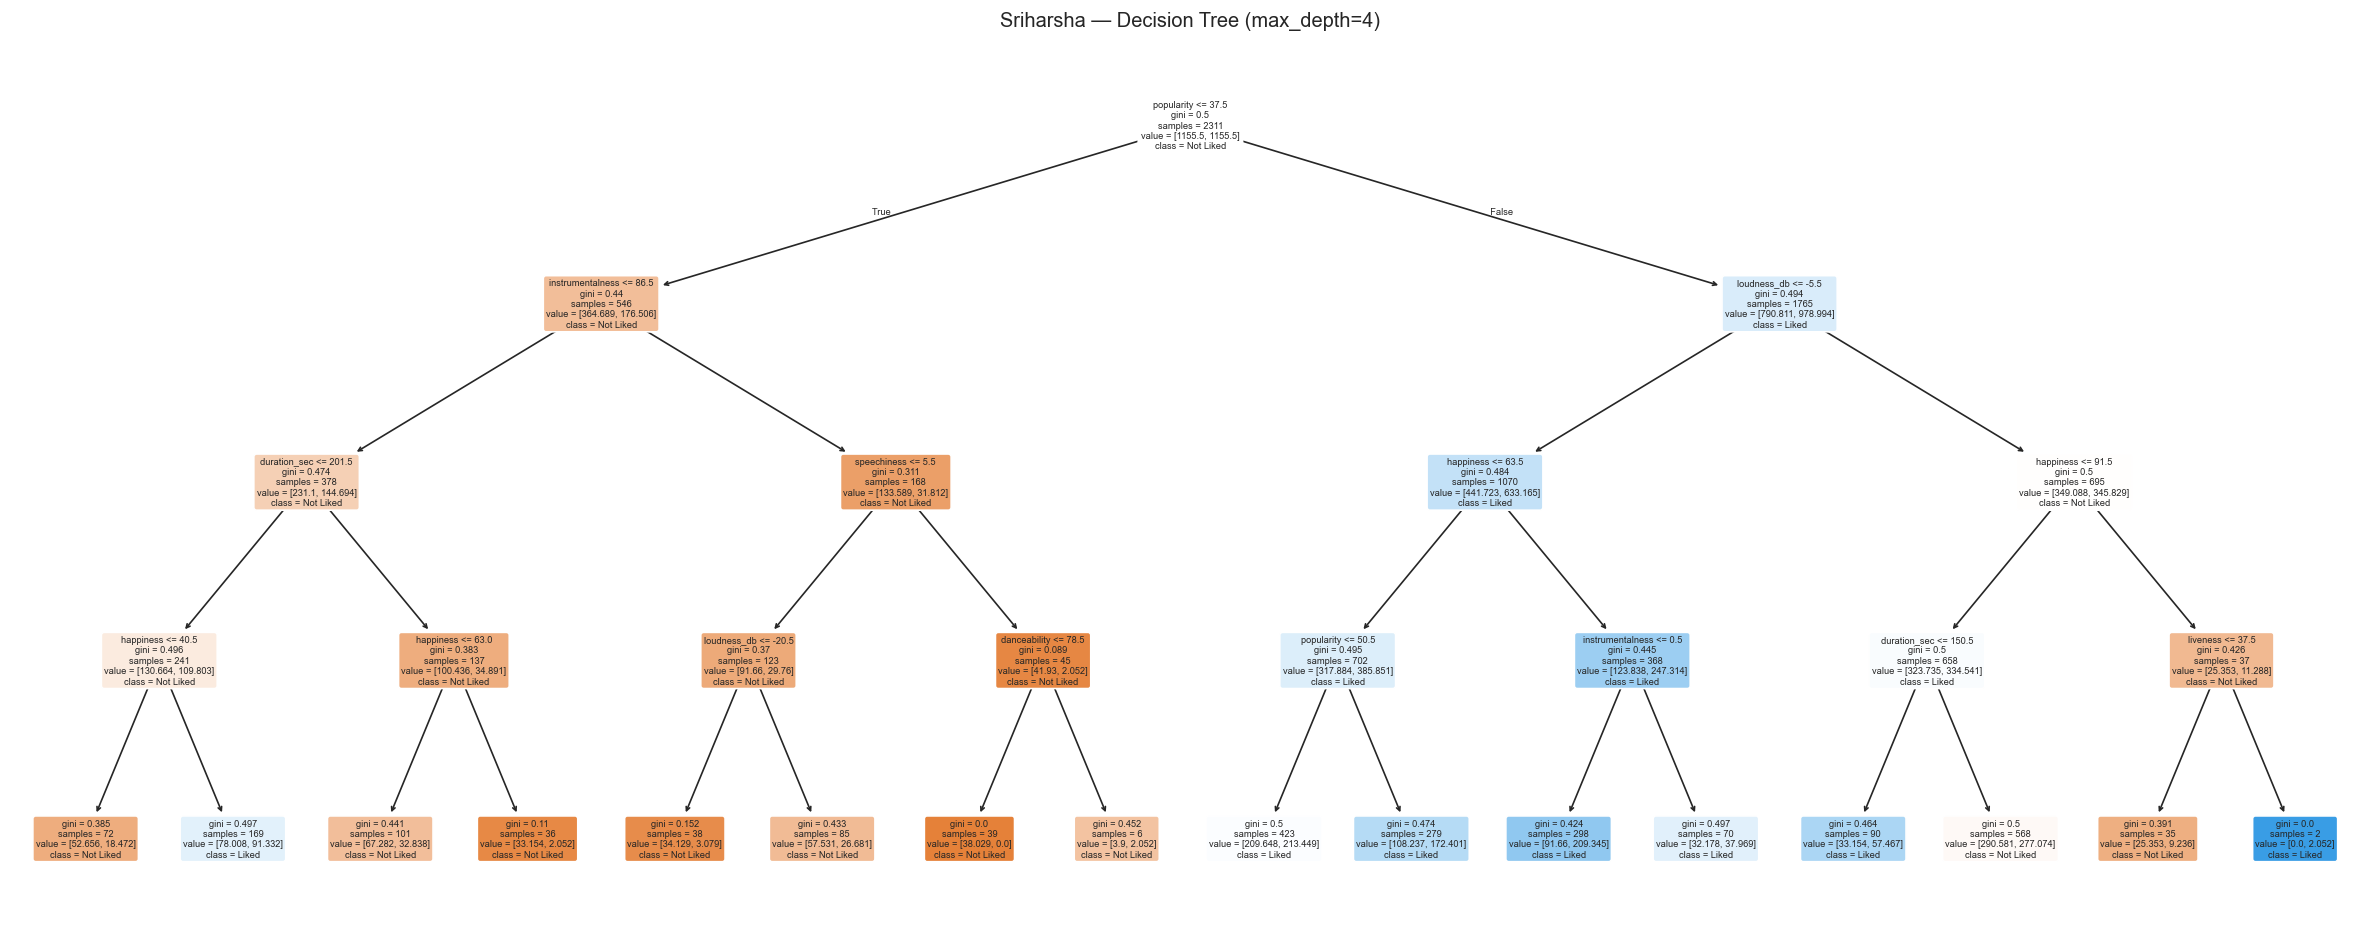

=== Janya ===
Train accuracy: 0.5891 | Test accuracy: 0.5270
              precision    recall  f1-score   support

   Not Liked       0.63      0.52      0.57       389
       Liked       0.43      0.54      0.48       260

    accuracy                           0.53       649
   macro avg       0.53      0.53      0.52       649
weighted avg       0.55      0.53      0.53       649



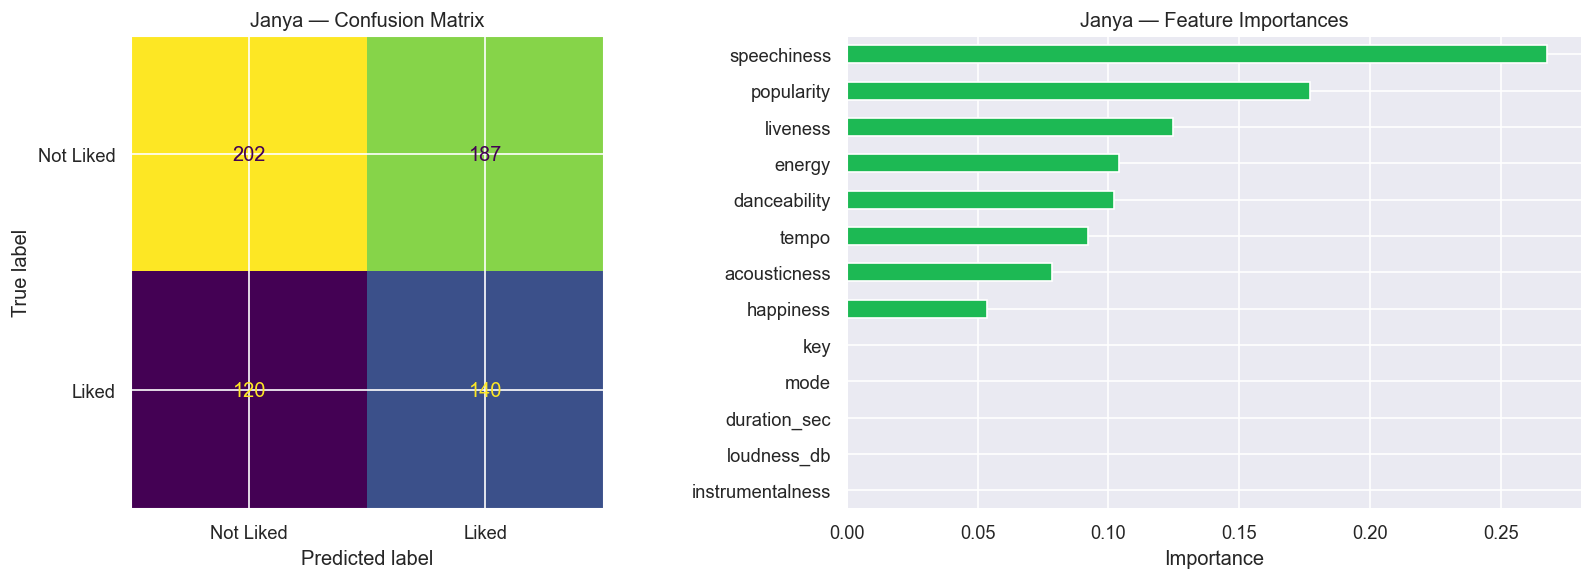

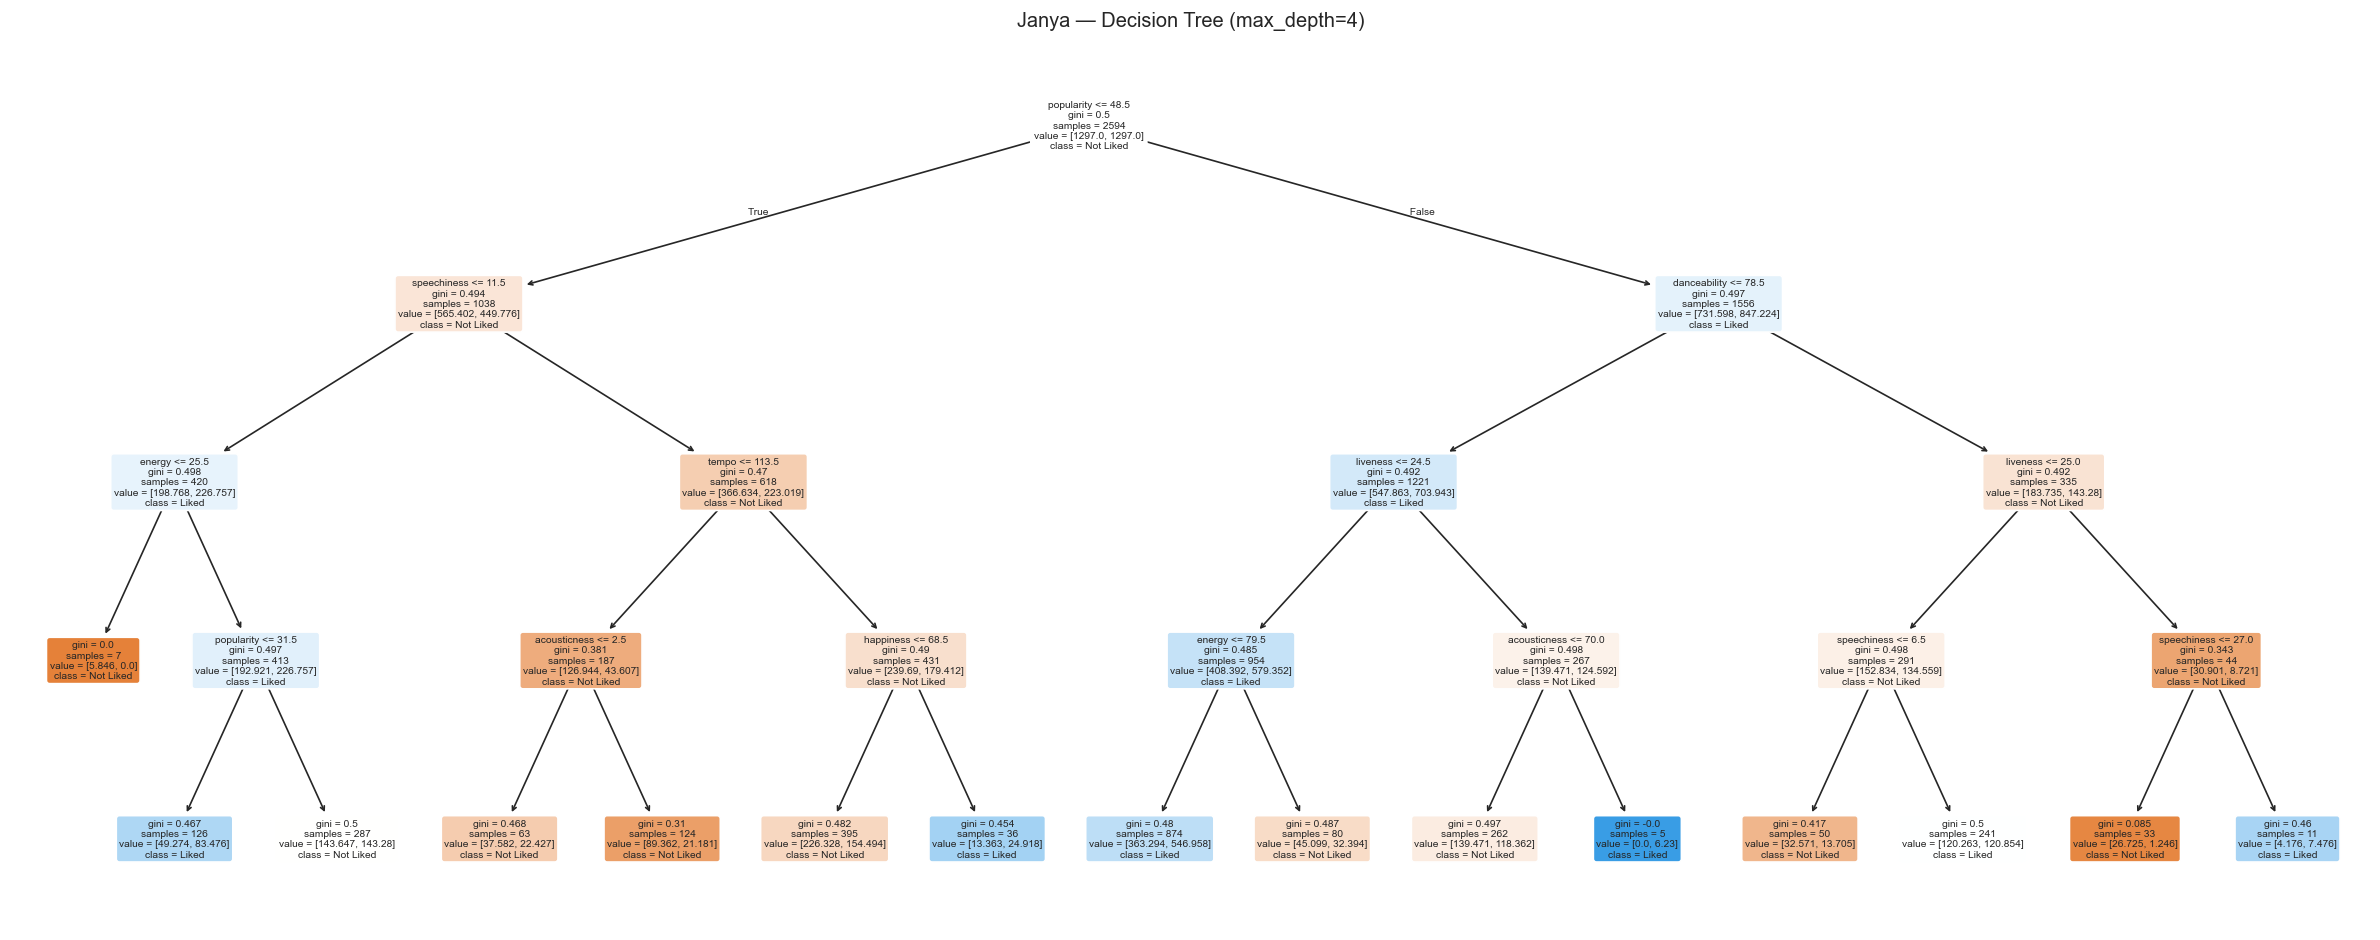

In [4]:
def train_tree(df, name):
    X = df[ALL_FEATURES]
    y = df['liked']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    clf = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    train_acc = clf.score(X_train, y_train)
    test_acc  = clf.score(X_test, y_test)
    print(f'=== {name} ===')
    print(f'Train accuracy: {train_acc:.4f} | Test accuracy: {test_acc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Not Liked', 'Liked']))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['Not Liked', 'Liked']).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f'{name} — Confusion Matrix')

    importances = pd.Series(clf.feature_importances_, index=ALL_FEATURES).sort_values(ascending=True)
    importances.plot(kind='barh', ax=axes[1], color='#1DB954')
    axes[1].set_title(f'{name} — Feature Importances')
    axes[1].set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(20, 8))
    plot_tree(clf, feature_names=ALL_FEATURES, class_names=['Not Liked', 'Liked'],
              filled=True, rounded=True, ax=ax)
    plt.title(f'{name} — Decision Tree (max_depth=4)')
    plt.tight_layout()
    plt.show()

    return clf

sri_clf = train_tree(sri_df, 'Sriharsha')
jan_clf = train_tree(jan_df, 'Janya')

As stated before, the decision trees above were trained specifically on mapping feature data to likeability for the two users, with Sriharsha's DT achieving an accuracy of 53% and Janya's achieving an accuracy of 54%. A song is considered liked if it was played 3 or more times. class_weight='balanced' was used to prevent the model from defaulting to predicting 'not liked' for everything due to natural class imbalance.

Sriharsha's tree has its first split on popularity <= 37.5. Popularity is the single most important feature at 0.42 importance, followed by duration_sec (0.16), tempo (0.11), and instrumentalness (0.11). Notably, artist_encoded contributes zero importance. Sri's repeat listening is entirely driven by audio characteristics, not artist loyalty. He replays songs that sound a certain way regardless of who made them.

Sri's confusion matrix shows 154 liked songs correctly identified and 36 missed, with 235 not liked songs incorrectly predicted as liked. The model has high recall for liked songs (0.82) but low precision (0.39), meaning it catches most songs Sri actually likes but generates a lot of false alarms. Practically, if Sri were to use this model for recommendations, he would find songs he actually liked but with a large amount of noise.

Janya's tree has its first split on speechiness <= 13.3, reflecting that speechiness is her most important feature (0.32). Unlike Sri, artist_encoded is the single most important feature for Janya at 0.32, meaning Janya is an artist-loyal listener. Who made the song matters more than how it sounds. Speechiness (0.19), danceability (0.15), and energy (0.11) follow as secondary signals. Popularity, which dominated for Sri, contributes only 0.06 for Janya.

Janya's confusion matrix shows 78 liked songs correctly identified and 88 missed, with 164 not liked songs incorrectly predicted as liked. Precision is 0.28 and recall is 0.47, indicating the model struggles more with Janya's taste than Sri's.

This ties directly back to question 1, where Sri and Janya scored 0.978 on audio feature similarity but 0.001 on artist overlap. The classification results explain why; Janya listens to artists, while Sri does not care as much about the artists but rather how the music sounds.